# OSM roads 

This notebook downloads the roads (highway) from OpenStreetMap (OSM), filters the categories of interest, sort them by priority and then applies to each noise segment the first category which is within 5 m distance. 
It adds to the dataframe also the distance between the segment and the road, and the length of the segment.
Finally, it saves all the data into a csv.

In [2]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [3]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Roads - OSM

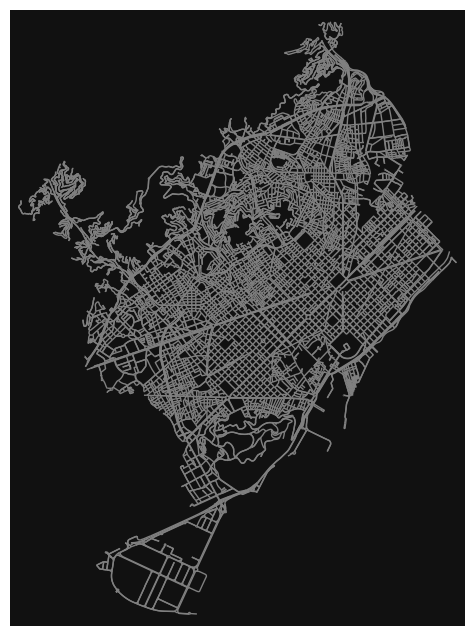

In [4]:
import osmnx as ox
G = ox.graph_from_place("Barcelona, Spain", network_type="drive")
ox.plot_graph(G, edge_color="gray", node_size=0)
ox.save_graphml(G, "barcelona.graphml")


## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as noise_streets
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_streets.crs)
roads.to_file("bcn_osmnx_edges.gpkg", layer="edges", driver="GPKG")

## Check features completeness

In [6]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False))
print("Checking public_transport..")
print(roads['lanes'].value_counts(dropna=False))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN                 14834
5                     207
6                     177
8                     154
9                     145
                    ...  
[7, 11]                 1
[4.6, 6]                1
[6, 15]                 1
9.6                     1
[4.9, 4.8, 5, 3]        1
Name: count, Length: 121, dtype: int64
Checking maxspeed..
maxspeed
30              9063
50              3892
20              1473
NaN              812
10               593
[20, 30]         316
80                98
[30, 50]          80
40                64
60                41
[20, 10]          20
[30, 10]          15
[10, 30]          14
[80, 50]           8
[30, 40]           7
70                 5
[40, 50]           5
[60, 50]           4
[80, 60]           4
[30, 40, 50]       4
[20, 50]           3
[20, 30, 50]       3
4                  2
[20, 10, 30]       2
[40, 60, 50]       2
[70, 50]           2
[10, 15]           1
[80, 60, 50]       1
[20, 40]           1
[30, 1]       

## Transform oneway from string to int

In [7]:
roads['oneway'] = [1 if x == 'yes' else 0 for x in roads['oneway']]

## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 16541, Filtered: 15149


## Plot road categories distribution

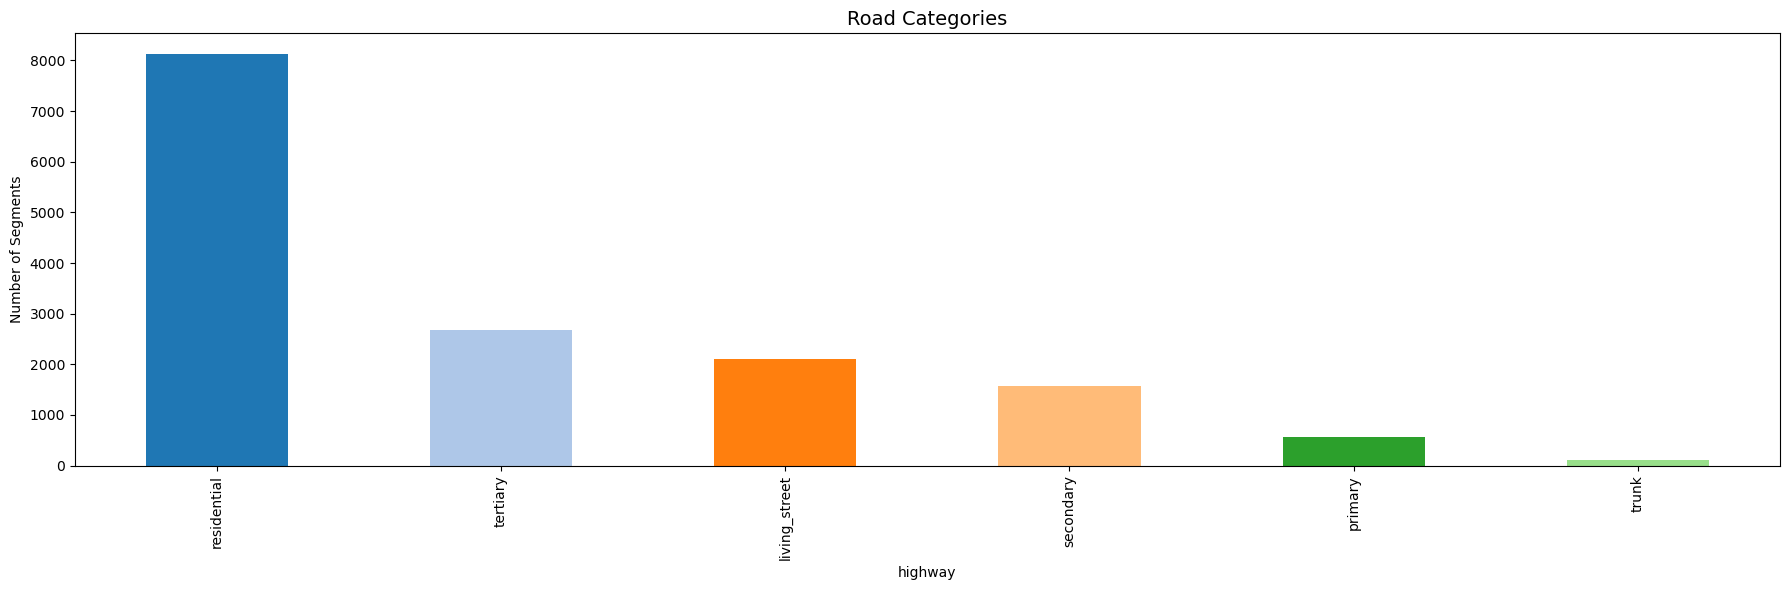

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


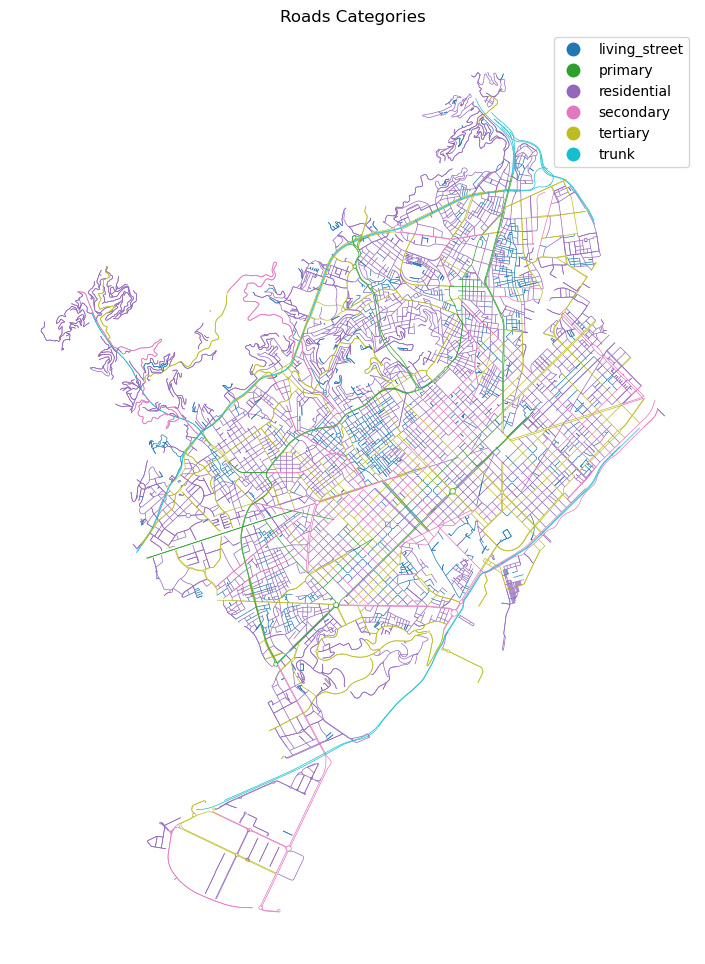

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign to each reoad segment the closest noise value

In [11]:
# Perform the spatial join
noise_roads = gpd.sjoin_nearest(roads_filtered, noise_streets, how='left', distance_col='distance', max_distance=None)

# Remove duplicate matches by keeping only the closest noise_street for each road
# The index of roads_filtered is preserved in the result as the left index
noise_roads = noise_roads.sort_values('distance').loc[~noise_roads.index.duplicated(keep='first')]

print(f"Before: {len(roads_filtered)}, Merged: {len(noise_roads)}")

Before: 15149, Merged: 15149


## Convert noise to numerical features

In [12]:
# Help function to convert dB string to int

def extract_min(range_str):
    if range_str == '< 40 dB(A)':
        return 0
    return int((range_str).split(' - ')[0])

print(extract_min('70 - 75 dB(A)'))

70


In [13]:
noise_roads['noise_day'] = noise_roads['TOTAL_D'].apply(extract_min)
noise_roads['noise_evening'] = noise_roads['TOTAL_E'].apply(extract_min)
noise_roads['noise_night'] = noise_roads['TOTAL_N'].apply(extract_min)

noise_roads.head()

osmid      highway lanes maxspeed  \
u           v         key                                                       
13845167536 847716886 0    [1449373108, 71213823]  residential   NaN       30   
21638869    30343583  0                   4809729  residential   NaN       30   
            242318729 0                   4079509     tertiary     2       30   
            30343672  0                   4079509     tertiary     2       30   
3055187877  431100338 0    [900167872, 900167871]  residential   NaN       30   

                                              name  oneway reversed  \
u           v         key                                             
13845167536 847716886 0     Carrer d'Albert Llanas       0    False   
21638869    30343583  0    Carrer de Grau i Torras       0    False   
            242318729 0    Carrer de Pepe Rubianes       0     True   
            30343672  0    Carrer de Pepe Rubianes       0    False   
3055187877  431100338 0         Carrer de Copèrnic       0    False   

                               length  \
u           v         key               
13845167536 847716886 0    401.507724   
21638869    30343583  0     90.400969   
            242318729 0     15.026538   
            30343672  0     15.374932   
3055187877  431100338 0     46.078887   

                                                                    geometry  \
u           v         key                                                      
13845167536 847716886 0    LINESTRING (429520.922 4585357.367, 429528.093...   
21638869    30343583  0    LINESTRING (432323.988 4581101.635, 432322.203...   
            242318729 0    LINESTRING (432323.988 4581101.635, 432309.474...   
            30343672  0    LINESTRING (432323.988 4581101.635, 432338.836...   
3055187877  431100338 0    LINESTRING (428285.093 4583684.318, 428281.562...   

                          access  ...          OCI_N     PATIS_D     PATIS_E  \
u           v         key         ...                                          
13845167536 847716886 0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
21638869    30343583  0      NaN  ...  45 - 50 dB(A)  < 40 dB(A)  < 40 dB(A)   
            242318729 0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
            30343672  0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
3055187877  431100338 0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   

                          geometry_type   start     end distance noise_day  \
u           v         key                                                    
13845167536 847716886 0            Line  429619  429661      0.0        55   
21638869    30343583  0            Line  432298  432312      0.0        55   
            242318729 0            Line  432298  432323      0.0        55   
            30343672  0            Line  432333  432337      0.0        60   
3055187877  431100338 0            Line  428242  428283      0.0        60   

                           noise_evening noise_night  
u           v         key                             
13845167536 847716886 0               55          50  
21638869    30343583  0               50          50  
            242318729 0               55          50  
            30343672  0               60          55  
3055187877  431100338 0               60          55  

[5 rows x 52 columns]

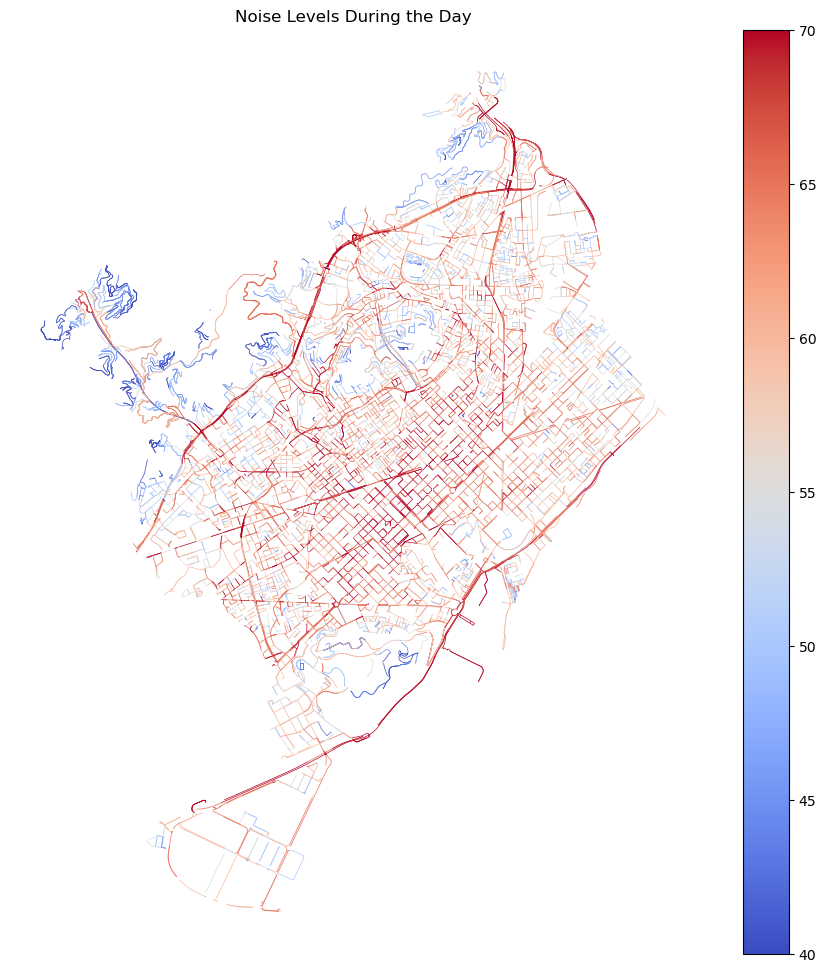

In [14]:
noise_roads['noise_day'] = noise_roads['noise_day'].clip(lower=40, upper=70)
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

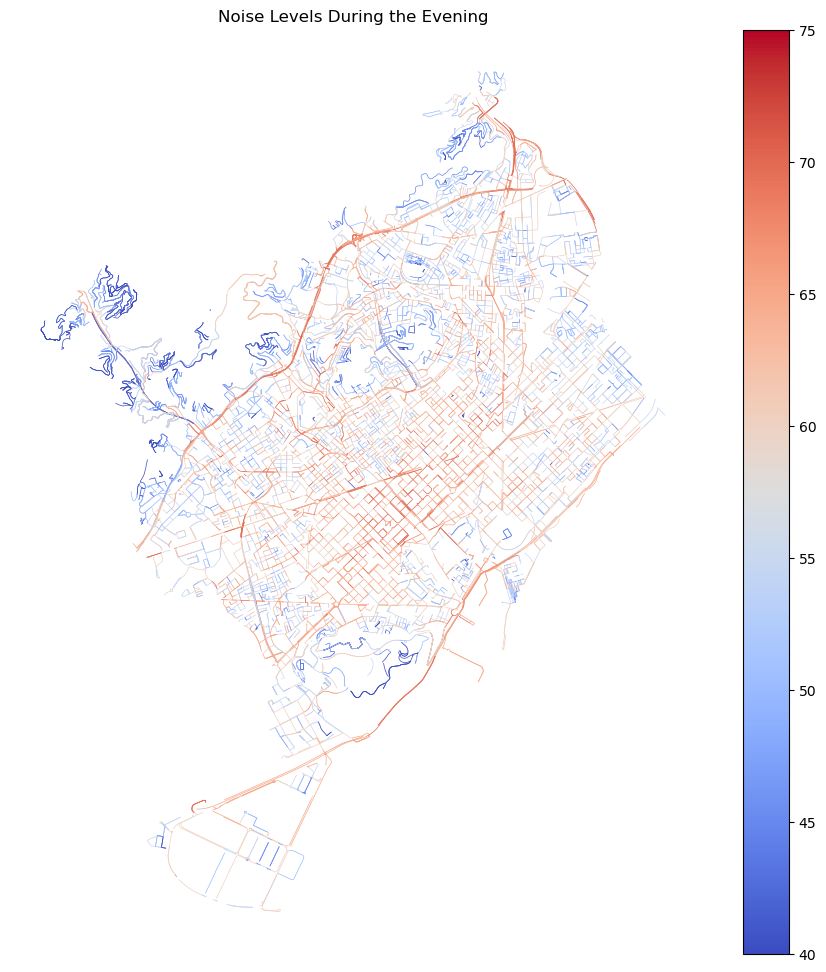

In [15]:
noise_roads['noise_evening'] = noise_roads['noise_evening'].clip(lower=40)
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', linewidth=0.5, legend=True, figsize=(12, 12), vmin=40, vmax=75)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

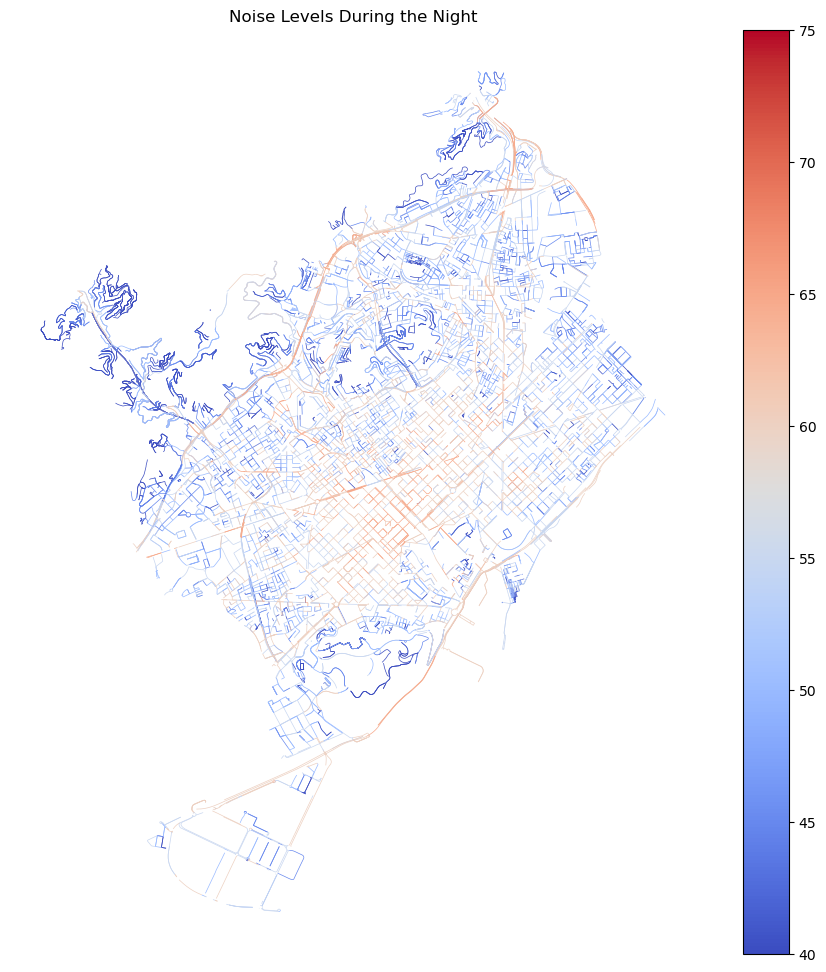

In [16]:
noise_roads['noise_night'] = noise_roads['noise_night'].clip(lower=40)
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', linewidth=0.5, legend=True, figsize=(12, 12),  vmin=40, vmax=75)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      8247
tertiary         2524
living_street    2118
secondary        1419
primary           624
trunk             217
Name: count, dtype: int64

In [ ]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

osmid      highway lanes maxspeed  \
u           v         key                                                       
13845167536 847716886 0    [1449373108, 71213823]  residential   NaN       30   
21638869    30343583  0                   4809729  residential   NaN       30   
            242318729 0                   4079509     tertiary     2       30   
            30343672  0                   4079509     tertiary     2       30   
3055187877  431100338 0    [900167872, 900167871]  residential   NaN       30   

                                              name  oneway reversed  \
u           v         key                                             
13845167536 847716886 0     Carrer d'Albert Llanas       0    False   
21638869    30343583  0    Carrer de Grau i Torras       0    False   
            242318729 0    Carrer de Pepe Rubianes       0     True   
            30343672  0    Carrer de Pepe Rubianes       0    False   
3055187877  431100338 0         Carrer de Copèrnic       0    False   

                               length  \
u           v         key               
13845167536 847716886 0    401.507724   
21638869    30343583  0     90.400969   
            242318729 0     15.026538   
            30343672  0     15.374932   
3055187877  431100338 0     46.078887   

                                                                    geometry  \
u           v         key                                                      
13845167536 847716886 0    LINESTRING (429520.922 4585357.367, 429528.093...   
21638869    30343583  0    LINESTRING (432323.988 4581101.635, 432322.203...   
            242318729 0    LINESTRING (432323.988 4581101.635, 432309.474...   
            30343672  0    LINESTRING (432323.988 4581101.635, 432338.836...   
3055187877  431100338 0    LINESTRING (428285.093 4583684.318, 428281.562...   

                          access  ...     PATIS_E geometry_type   start  \
u           v         key         ...                                     
13845167536 847716886 0      NaN  ...  < 40 dB(A)          Line  429619   
21638869    30343583  0      NaN  ...  < 40 dB(A)          Line  432298   
            242318729 0      NaN  ...  < 40 dB(A)          Line  432298   
            30343672  0      NaN  ...  < 40 dB(A)          Line  432333   
3055187877  431100338 0      NaN  ...  < 40 dB(A)          Line  428242   

                              end distance noise_day noise_evening  \
u           v         key                                            
13845167536 847716886 0    429661      0.0        55            55   
21638869    30343583  0    432312      0.0        55            50   
            242318729 0    432323      0.0        55            55   
            30343672  0    432337      0.0        60            60   
3055187877  431100338 0    428283      0.0        60            60   

                          noise_night  road_category category_code  
u           v         key                                           
13845167536 847716886 0            50    residential             5  
21638869    30343583  0            50    residential             5  
            242318729 0            50       tertiary             4  
            30343672  0            55       tertiary             4  
3055187877  431100338 0            55    residential             5  

[5 rows x 54 columns]

## Calculate distance to major road

In [ ]:
# Filter target roads
target_categories = ['secondary', 'primary', 'trunk']
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,start,end,distance,noise_day,noise_evening,noise_night,road_category,category_code,dist_to_main,index_right
0,"[1449373108, 71213823]",residential,NaN,30,Carrer d'Albert Llanas,0,False,401.507724,"LINESTRING (429520.922 4585357.367, 429528.093...",NaN,...,429619,429661,0.0,55,55,50,residential,5,258.681126,1032
1,4809729,residential,NaN,30,Carrer de Grau i Torras,0,False,90.400969,"LINESTRING (432323.988 4581101.635, 432322.203...",NaN,...,432298,432312,0.0,55,50,50,residential,5,429.190460,276
2,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,True,15.026538,"LINESTRING (432323.988 4581101.635, 432309.474...",NaN,...,432298,432323,0.0,55,55,50,tertiary,4,512.333789,276
3,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,False,15.374932,"LINESTRING (432323.988 4581101.635, 432338.836...",NaN,...,432333,432337,0.0,60,60,55,tertiary,4,516.423077,276
4,"[900167872, 900167871]",residential,NaN,30,Carrer de Copèrnic,0,False,46.078887,"LINESTRING (428285.093 4583684.318, 428281.562...",NaN,...,428242,428283,0.0,60,60,55,residential,5,214.041852,125


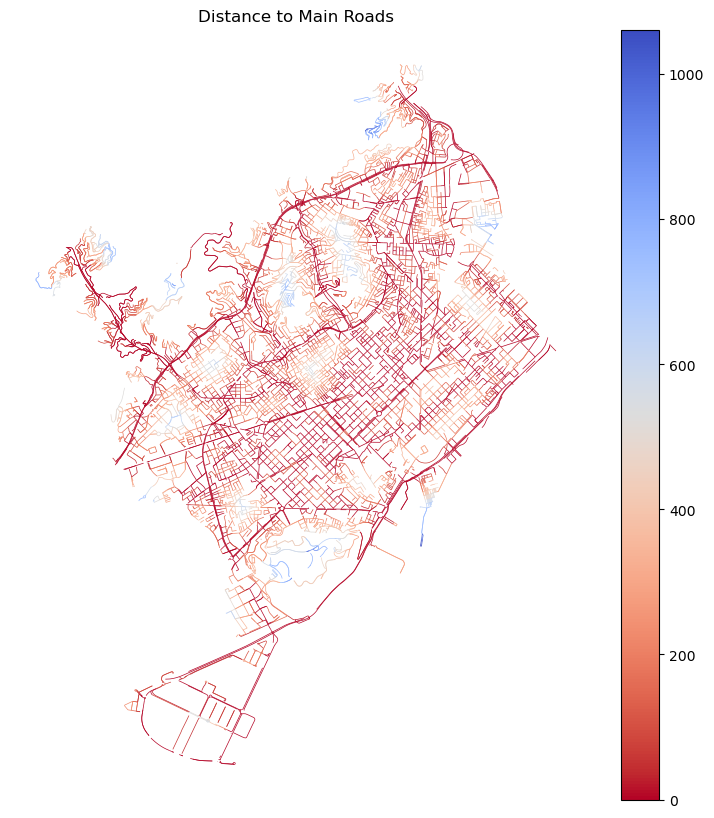

In [39]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

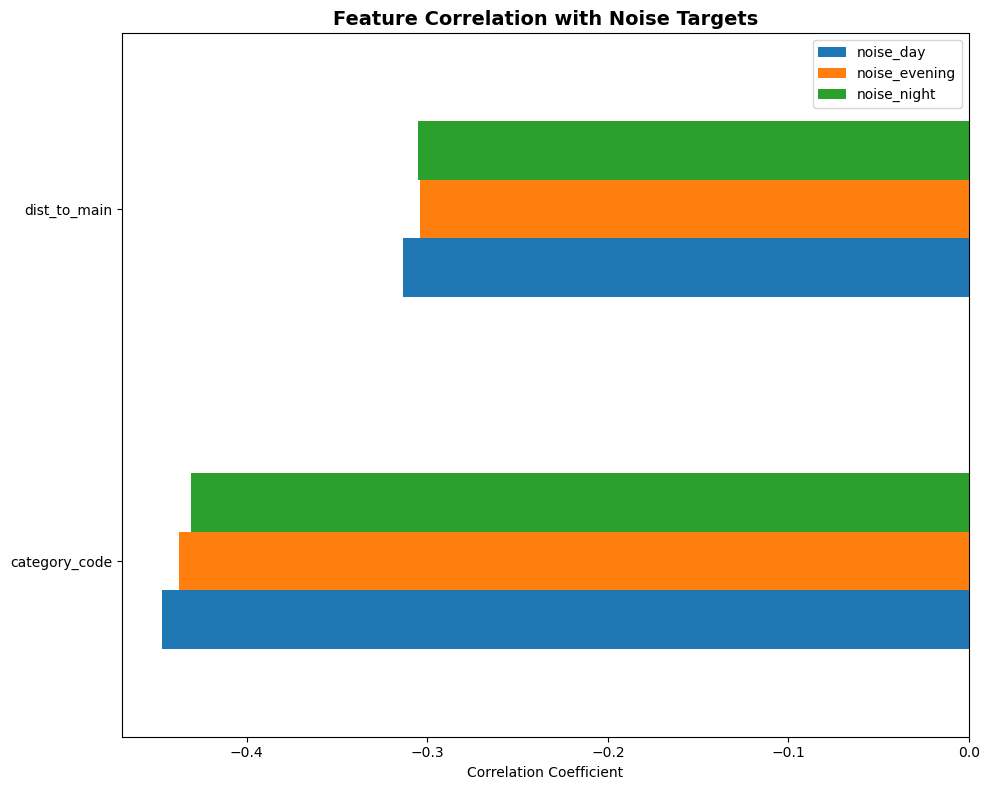

               noise_day  noise_evening  noise_night
dist_to_main   -0.313383      -0.304266    -0.305057
category_code  -0.446911      -0.437609    -0.431215


In [35]:
# Extract correlations with noise predictions
dataset_filtered = noise_roads[['noise_day', 'noise_evening', 'noise_night','dist_to_main','category_code']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Create data frame

In [36]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_length": noise_roads['geometry'].length,
    "road_category": noise_roads['category_code'], 
    "dist_to_main": noise_roads['dist_to_main'], 
}).fillna(0) #fillna(0) to replace any NaN values with 0
dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()


,road_id,noise_day,noise_evening,noise_night,road_length,road_category,dist_to_main
0,13845167536_847716886_0,55,55,50,401.483629,5,661.587375
1,21638869_30343583_0,55,50,50,90.289544,5,429.190460
2,21638869_242318729_0,55,55,50,15.055894,4,512.333789
3,21638869_30343672_0,60,60,55,15.404960,4,516.423077
4,3055187877_431100338_0,60,60,55,46.142160,5,214.041852


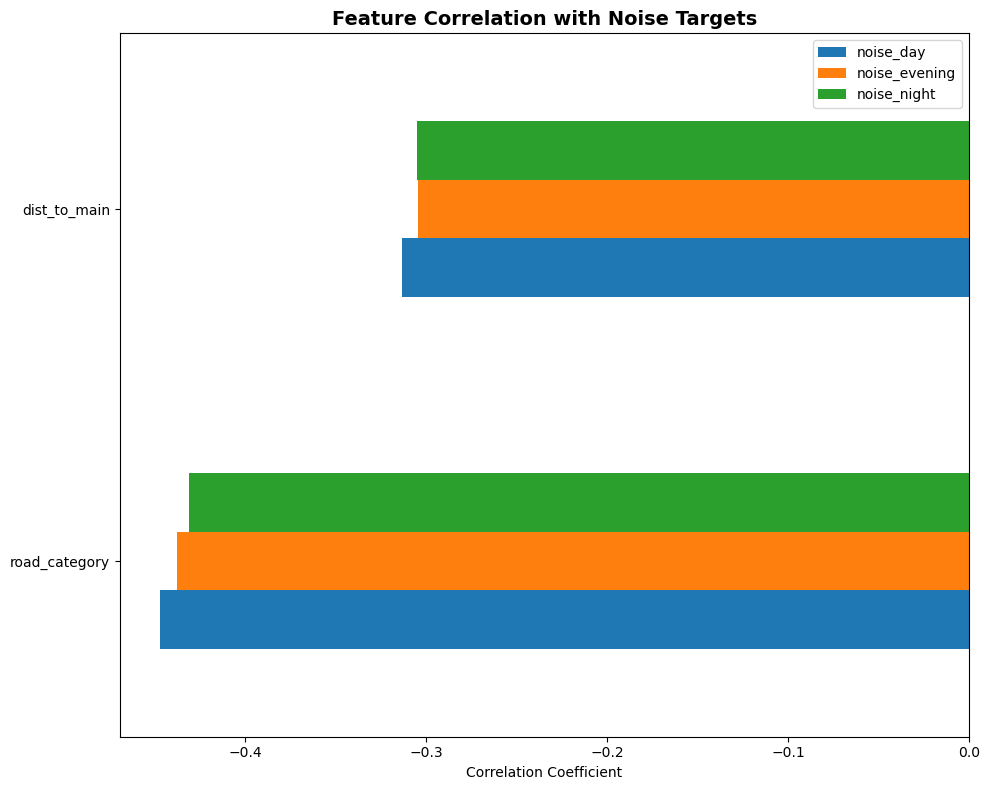

               noise_day  noise_evening  noise_night
dist_to_main   -0.313383      -0.304266    -0.305057
road_category  -0.446911      -0.437609    -0.431215


In [37]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night','dist_to_main','road_category']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [ ]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_features.csv"), index=False)
print("Exported osm_roads_features.csv")

Exported osm_roads_features.csv
